# DAY 9 — Complete Statistics for Data Analytics, Data Science & AI

**Statistics is the language of data. Every DS/AI job interview tests these.**

---

## Complete Topics List
| # | Topic | Category |
|---|-------|----------|
| 1 | Types of Data (Nominal, Ordinal, Discrete, Continuous) | Fundamentals |
| 2 | Population vs Sample + Sampling Methods | Fundamentals |
| 3 | Measures of Central Tendency (Mean, Median, Mode) | Descriptive |
| 4 | Weighted, Geometric, Harmonic Mean + Coefficient of Variation | Descriptive |
| 5 | Measures of Spread (Range, Variance, Std Dev, IQR) | Descriptive |
| 6 | Boxplot + Violin Plot | Visualization |
| 7 | Skewness | Shape |
| 8 | Kurtosis | Shape |
| 9 | Probability Basics + Conditional Probability | Probability |
| 10 | Probability Distributions: Binomial & Poisson | Probability |
| 11 | Bayes' Theorem | Probability / AI |
| 12 | Percentiles & Quartiles | Descriptive |
| 13 | Normal Distribution + 68-95-99.7 Rule | Distributions |
| 14 | Central Limit Theorem (CLT) | Inference |
| 15 | Z-Score (Standardization) | Inference |
| 16 | Outlier Detection (IQR + Z-Score) | Data Quality |
| 17 | Normality Testing (Shapiro-Wilk + Q-Q Plot) | Inference |
| 18 | Covariance | Relationships |
| 19 | Correlation: Pearson & Spearman + Heatmap | Relationships |
| 20 | Simple Linear Regression: R², RMSE, MAE, Residuals | ML Bridge |
| 21 | Hypothesis Testing: t-test & chi-square | Inference |
| 22 | ANOVA (Comparing 3+ Groups) | Inference |
| 23 | Type I & II Errors + Statistical Power + Effect Size | Inference |
| 24 | Confidence Intervals (90%, 95%, 99%) | Inference |
| 25 | A/B Testing (Real-World Application) | Applied |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (ttest_ind, ttest_1samp, ttest_rel,
                         chi2_contingency, norm, binom, poisson,
                         f_oneway, shapiro, probplot)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Types of Data

```
Data
├── Quantitative (Numbers)
│   ├── Discrete   → Countable (students: 30, 31, 32)
│   └── Continuous → Any value (height: 5.7, 5.71, 5.712)
└── Qualitative (Categories)
    ├── Nominal    → No order (city: Delhi, Mumbai)
    └── Ordinal    → Ordered (rating: Poor < Good < Excellent)
```

In [3]:
examples = pd.DataFrame({
    'Data': ['Number of students in class', 'Student height in cm', 'City names', 'Grade (A/B/C/D)'],
    'Type': ['Discrete', 'Continuous', 'Nominal', 'Ordinal'],
    'Category': ['Quantitative', 'Quantitative', 'Qualitative', 'Qualitative']
})
print('Examples of Data Types:')
print(examples.to_string(index=True))

Examples of Data Types:
                          Data        Type      Category
0  Number of students in class    Discrete  Quantitative
1         Student height in cm  Continuous  Quantitative
2                   City names     Nominal   Qualitative
3              Grade (A/B/C/D)     Ordinal   Qualitative


---
## 1B. Population vs Sample & Sampling Methods

**Population** = The entire group you want to study (all students in India)
**Sample** = A smaller subset you actually collect data from (500 students from Delhi)

Why sample? Collecting data from the whole population is:
- Too expensive
- Too slow
- Sometimes impossible

### Types of Sampling:
| Method | How it works | Example |
|--------|-------------|---------|
| **Simple Random** | Every individual has equal chance | Pick 100 students randomly from a list |
| **Stratified** | Divide into groups, sample from each | Sample from each state proportionally |
| **Systematic** | Pick every Nth person | Every 10th customer from a list |
| **Cluster** | Pick random groups entirely | Randomly pick 5 schools, survey all students |
| **Convenience** | Pick whoever is easy to reach | Survey friends — BIASED! |

### Sampling Bias:
Bad sampling leads to wrong conclusions. Example:
- Surveying only urban people to understand India's average income → BIASED
- Online survey assumes everyone has internet → BIASED

In [4]:
np.random.seed(42)

# Simulate population of 10,000 student heights
population = np.random.normal(165, 15, 10000)

# Different sampling methods
n = 100

# 1. Simple Random Sample
simple_random = population[np.random.choice(len(population), n, replace=False)]

# 2. Systematic Sample (every 100th person)
systematic = population[::100][:n]

# 3. Stratified Sample (50 from top half, 50 from bottom half)
top_half    = population[population > 165]
bottom_half = population[population <= 165]
stratified  = np.concatenate([
    top_half[np.random.choice(len(top_half), 50, replace=False)],
    bottom_half[np.random.choice(len(bottom_half), 50, replace=False)]
])

print('=== Sampling Methods Comparison ===')
print(f'Population (N=10,000):  Mean = {population.mean():.2f} cm, Std = {population.std():.2f}')
print(f'Simple Random (n={n}):    Mean = {simple_random.mean():.2f} cm, Std = {simple_random.std():.2f}')
print(f'Systematic (n={n}):       Mean = {systematic.mean():.2f} cm, Std = {systematic.std():.2f}')
print(f'Stratified (n={n}):       Mean = {stratified.mean():.2f} cm, Std = {stratified.std():.2f}')

=== Sampling Methods Comparison ===
Population (N=10,000):  Mean = 164.97 cm, Std = 15.05
Simple Random (n=100):    Mean = 166.75 cm, Std = 15.98
Systematic (n=100):       Mean = 164.61 cm, Std = 15.46
Stratified (n=100):       Mean = 164.41 cm, Std = 15.57


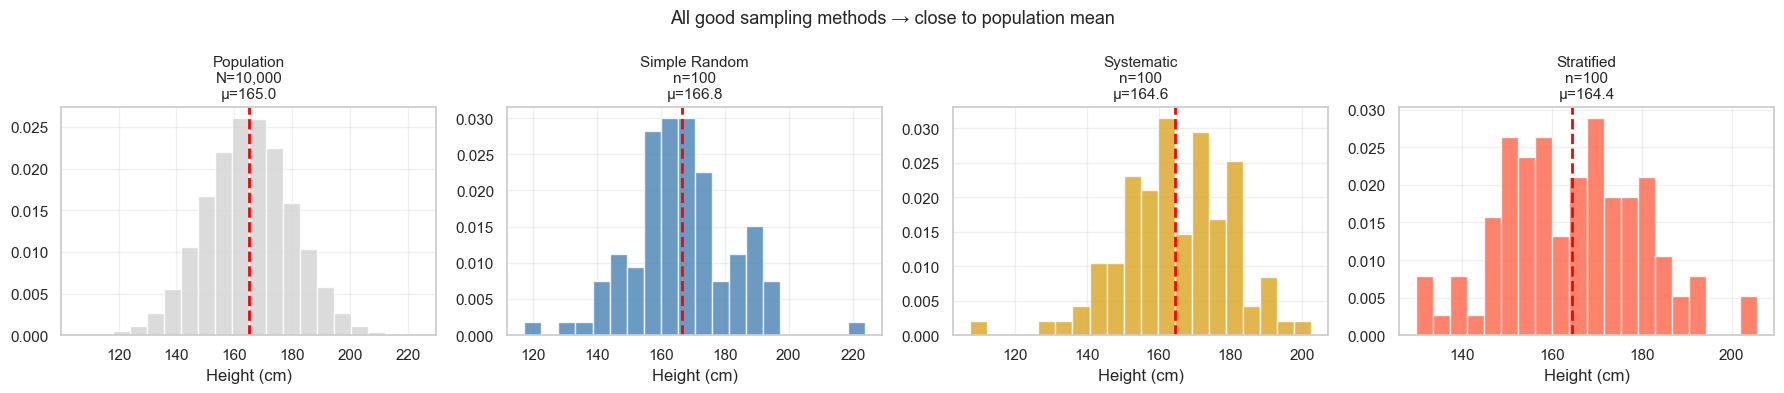

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, data, title, color in [
    (axes[0], population,    f'Population\nN=10,000\nμ={population.mean():.1f}', 'lightgray'),
    (axes[1], simple_random, f'Simple Random\nn={n}\nμ={simple_random.mean():.1f}', 'steelblue'),
    (axes[2], systematic,    f'Systematic\nn={n}\nμ={systematic.mean():.1f}', 'goldenrod'),
    (axes[3], stratified,    f'Stratified\nn={n}\nμ={stratified.mean():.1f}', 'tomato'),
]:
    ax.hist(data, bins=20, color=color, edgecolor='white', alpha=0.8, density=True)
    ax.axvline(data.mean(), color='red', linestyle='--', lw=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Height (cm)')
    ax.grid(True, alpha=0.3)

plt.suptitle('All good sampling methods → close to population mean', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Measures of Central Tendency

Answers: "Where is the center of data?"

In [6]:
marks = [72, 65, 88, 55, 92, 72, 78, 83, 65, 72, 95, 60]

mean   = np.mean(marks)
median = np.median(marks)
mode   = stats.mode(marks, keepdims=True)

print(f'Data: {sorted(marks)}')
print(f'\nMean   (Average)         : {mean:.2f}')
print(f'Median (Middle Value)    : {median}')
print(f'Mode   (Most Frequent)   : {mode.mode[0]} (appears {mode.count[0]} times)')

print('\n--- When to use what? ---')
print('Mean   → Symmetric data, no outliers (example: test scores)')
print('Median → Skewed data or outliers (example: salary, house price)')
print('Mode   → Categorical data (example: most popular product)')

Data: [55, 60, 65, 65, 72, 72, 72, 78, 83, 88, 92, 95]

Mean   (Average)         : 74.75
Median (Middle Value)    : 72.0
Mode   (Most Frequent)   : 72 (appears 3 times)

--- When to use what? ---
Mean   → Symmetric data, no outliers (example: test scores)
Median → Skewed data or outliers (example: salary, house price)
Mode   → Categorical data (example: most popular product)


In [7]:
# Effect of outlier on Mean vs Median
normal_salaries  = [40000, 45000, 50000, 52000, 48000, 46000, 51000]
ceo_salary       = 5000000
with_ceo         = normal_salaries + [ceo_salary]

print('Without CEO salary:')
print(f'  Mean   = Rs {np.mean(normal_salaries):,.0f}')
print(f'  Median = Rs {np.median(normal_salaries):,.0f}')

print('\nWith CEO salary (outlier):')
print(f'  Mean   = Rs {np.mean(with_ceo):,.0f}   ← DISTORTED by outlier')
print(f'  Median = Rs {np.median(with_ceo):,.0f}   ← Not affected')
print('\n→ Use Median for salary analysis!')

Without CEO salary:
  Mean   = Rs 47,429
  Median = Rs 48,000

With CEO salary (outlier):
  Mean   = Rs 666,500   ← DISTORTED by outlier
  Median = Rs 49,000   ← Not affected

→ Use Median for salary analysis!


---
## 2B. Other Types of Mean & Coefficient of Variation

### Weighted Mean
Used when some values are more important than others.
Example: Final grade = 40% midterm + 60% final exam

### Geometric Mean

Used for growth rates, returns, ratios.
Example: If investment grew 10%, 20%, -5% → use geometric mean, not arithmetic mean

### Harmonic Mean
Used for rates and speeds.
Example: Average speed when same distance covered at different speeds

### Coefficient of Variation (CV)
`CV = (Std Dev / Mean) × 100%`
Used to compare spread of datasets with different units or scales.
- Low CV → data is consistent
- High CV → data is highly variable

In [8]:
# ── Weighted Mean ─────────────────────────────────────────────────────────────
midterm_score = 70
final_score   = 85
midterm_weight = 0.40
final_weight   = 0.60

arithmetic_mean = (midterm_score + final_score) / 2
weighted_mean   = midterm_score * midterm_weight + final_score * final_weight

print('=== Weighted Mean: Exam Grade ===')
print(f'Midterm: {midterm_score} (weight 40%)  |  Final: {final_score} (weight 60%)')
print(f'Arithmetic Mean = {arithmetic_mean:.1f}  (WRONG — treats both equally)')
print(f'Weighted Mean   = {weighted_mean:.1f}  (CORRECT — final matters more)')

# ── Geometric Mean ─────────────────────────────────────────────────────────────
print('\n=== Geometric Mean: Investment Returns ===')
returns = [10, 20, -5, 15, 8]   # yearly % returns
growth_factors = [1 + r/100 for r in returns]
geo_mean = stats.gmean(growth_factors) - 1
arith_mean = np.mean(returns) / 100
print(f'Yearly returns: {returns}%')
print(f'Arithmetic mean: {arith_mean*100:.2f}%  (slightly misleading)')
print(f'Geometric mean:  {geo_mean*100:.2f}%  (true compound growth rate)')
print(f'Over 5 years: Rs 100 → Rs {100 * np.prod(growth_factors):.2f} (actual)')

# ── Harmonic Mean ─────────────────────────────────────────────────────────────
print('\n=== Harmonic Mean: Speed Example ===')
speed_go   = 60   # km/h (going)
speed_back = 40   # km/h (return)
arith_speed = (speed_go + speed_back) / 2
harm_speed  = stats.hmean([speed_go, speed_back])
print(f'Going: {speed_go} km/h  |  Return: {speed_back} km/h')
print(f'Arithmetic Mean Speed = {arith_speed:.1f} km/h  (WRONG!)')
print(f'Harmonic Mean Speed   = {harm_speed:.1f} km/h  (CORRECT for same distance)')

# ── Coefficient of Variation ──────────────────────────────────────────────────
print('\n=== Coefficient of Variation: Comparing Consistency ===')
maths_scores    = np.array([85, 88, 82, 90, 86, 84, 89, 87])
english_scores  = np.array([60, 95, 40, 88, 72, 55, 91, 78])

for name, data in [('Maths', maths_scores), ('English', english_scores)]:
    cv = (np.std(data) / np.mean(data)) * 100
    print(f'{name:10s}:  Mean={np.mean(data):.1f}  Std={np.std(data):.1f}  CV={cv:.1f}%  →  {"Consistent" if cv < 15 else "Highly Variable"}')

=== Weighted Mean: Exam Grade ===
Midterm: 70 (weight 40%)  |  Final: 85 (weight 60%)
Arithmetic Mean = 77.5  (WRONG — treats both equally)
Weighted Mean   = 79.0  (CORRECT — final matters more)

=== Geometric Mean: Investment Returns ===
Yearly returns: [10, 20, -5, 15, 8]%
Arithmetic mean: 9.60%  (slightly misleading)
Geometric mean:  9.27%  (true compound growth rate)
Over 5 years: Rs 100 → Rs 155.75 (actual)

=== Harmonic Mean: Speed Example ===
Going: 60 km/h  |  Return: 40 km/h
Arithmetic Mean Speed = 50.0 km/h  (WRONG!)
Harmonic Mean Speed   = 48.0 km/h  (CORRECT for same distance)

=== Coefficient of Variation: Comparing Consistency ===
Maths     :  Mean=86.4  Std=2.5  CV=2.9%  →  Consistent
English   :  Mean=72.4  Std=18.2  CV=25.1%  →  Highly Variable


---
## 3. Measures of Spread

Answers: "How spread out is the data?"

In [9]:
data = np.array([55, 60, 65, 70, 72, 75, 78, 82, 85, 88, 92, 95])

print(f'Data: {data}')
print()
print(f'Range       = Max - Min = {data.max()} - {data.min()} = {data.max()-data.min()}')
print(f'Variance    = {np.var(data):.2f}  (average squared deviation)')
print(f'Std Dev     = {np.std(data):.2f}  (square root of variance)')
print()
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
print(f'Q1 (25th %) = {Q1}')
print(f'Q3 (75th %) = {Q3}')
print(f'IQR         = Q3 - Q1 = {IQR}')
print()
print('--- Interpretation ---')
print(f'Low std dev  = data is clustered close to mean')
print(f'High std dev = data is widely spread')

Data: [55 60 65 70 72 75 78 82 85 88 92 95]

Range       = Max - Min = 95 - 55 = 40
Variance    = 145.91  (average squared deviation)
Std Dev     = 12.08  (square root of variance)

Q1 (25th %) = 68.75
Q3 (75th %) = 85.75
IQR         = Q3 - Q1 = 17.0

--- Interpretation ---
Low std dev  = data is clustered close to mean
High std dev = data is widely spread


---
## 4. Boxplot — Visualizing Spread

A **boxplot** shows the 5-number summary in one chart:
`Min → Q1 → Median → Q3 → Max`

- The **box** = middle 50% of data (IQR)
- The **line** inside box = Median
- The **whiskers** = range of normal data
- **Dots beyond whiskers** = Outliers

Math     → Min=44  Q1=64.0  Median=68.7  Q3=74.1  Max=89  IQR=10.1
English  → Min=27  Q1=48.9  Median=66.7  Q3=75.8  Max=119  IQR=26.9
Science  → Min=54  Q1=74.8  Median=80.8  Q3=85.6  Max=111  IQR=10.9


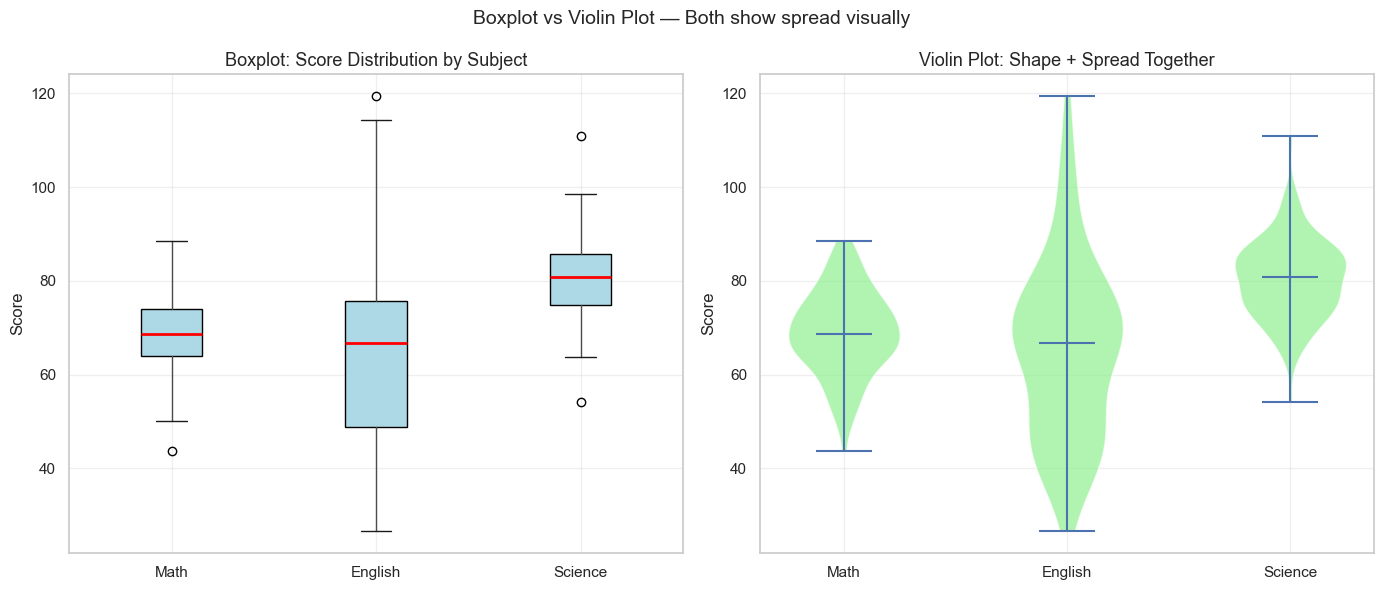

In [10]:
np.random.seed(42)
math_scores    = np.random.normal(70, 10, 100).tolist() + [20, 110]   # 2 outliers
english_scores = np.random.normal(65, 20, 100).tolist()
science_scores = np.random.normal(80,  8, 100).tolist() + [15]        # 1 outlier

df_box = pd.DataFrame({
    'Math':    math_scores[:100],
    'English': english_scores,
    'Science': science_scores[:100]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
df_box.boxplot(ax=axes[0], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot: Score Distribution by Subject', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3)

# 5-number summary table
for col in df_box.columns:
    q1 = df_box[col].quantile(0.25)
    med = df_box[col].median()
    q3 = df_box[col].quantile(0.75)
    print(f'{col:8s} → Min={df_box[col].min():.0f}  Q1={q1:.1f}  Median={med:.1f}  Q3={q3:.1f}  Max={df_box[col].max():.0f}  IQR={q3-q1:.1f}')

# Violin plot (shows distribution shape + boxplot)
parts = axes[1].violinplot([df_box['Math'], df_box['English'], df_box['Science']],
                            showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightgreen')
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['Math', 'English', 'Science'])
axes[1].set_title('Violin Plot: Shape + Spread Together', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Boxplot vs Violin Plot — Both show spread visually', fontsize=14)
plt.tight_layout()
plt.show()

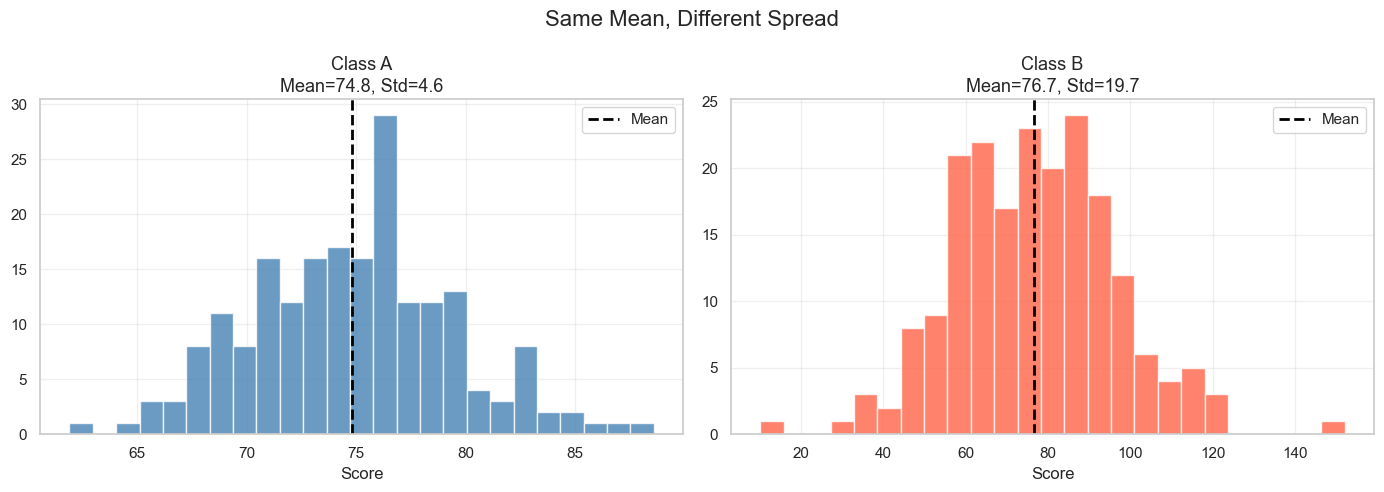

In [11]:
# Visual: Two classes same mean, different spread
np.random.seed(42)
class_a = np.random.normal(75, 5, 200)   # mean=75, std=5 (consistent)
class_b = np.random.normal(75, 20, 200)  # mean=75, std=20 (variable)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, label, color in [
    (axes[0], class_a, f'Class A\nMean={class_a.mean():.1f}, Std={class_a.std():.1f}', 'steelblue'),
    (axes[1], class_b, f'Class B\nMean={class_b.mean():.1f}, Std={class_b.std():.1f}', 'tomato')
]:
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='black', linestyle='--', lw=2, label='Mean')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Same Mean, Different Spread', fontsize=16)
plt.tight_layout()
plt.show()

---
## 4. Skewness and Kurtosis

**Skewness** = How asymmetric the distribution is

- Skew = 0 → Symmetric (normal)
- Skew > 0 → Right skewed ( mean > median)
- Skew < 0 → Left skewed ( mean < median)

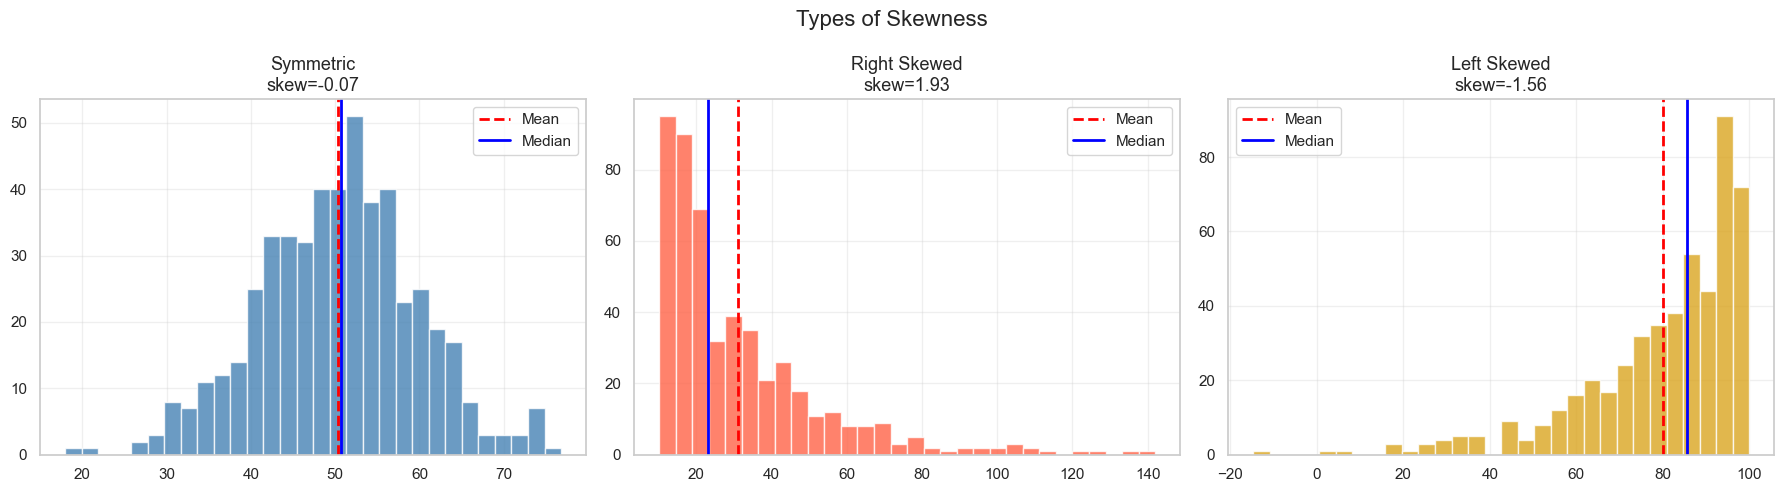

Real-world examples:
Right skewed → Salaries, Home prices, Company revenue
Left skewed  → Exam scores (when exam is easy)
Symmetric    → Height, IQ scores, measurement errors


In [21]:
np.random.seed(10)
symmetric   = np.random.normal(50, 10, 500)
right_skew  = np.random.exponential(scale=20, size=500) + 10
left_skew   = 100 - np.random.exponential(scale=20, size=500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title, color in [
    (axes[0], symmetric,  f'Symmetric\nskew={stats.skew(symmetric):.2f}', 'steelblue'),
    (axes[1], right_skew, f'Right Skewed\nskew={stats.skew(right_skew):.2f}', 'tomato'),
    (axes[2], left_skew,  f'Left Skewed\nskew={stats.skew(left_skew):.2f}', 'goldenrod')
]:
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(data), color='red', linestyle='--', lw=2, label='Mean')
    ax.axvline(np.median(data), color='blue', linestyle='-', lw=2, label='Median')
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Types of Skewness', fontsize=16)
plt.tight_layout()
plt.show()

print('Real-world examples:')
print('Right skewed → Salaries, Home prices, Company revenue')
print('Left skewed  → Exam scores (when exam is easy)')
print('Symmetric    → Height, IQ scores, measurement errors')

---
## 5B. Kurtosis — Peakedness of Distribution

**Kurtosis** measures how sharp/flat the peak of a distribution is compared to a normal distribution.

| Kurtosis | Type | Meaning |
|----------|------|---------|
| = 3 (excess = 0) | Mesokurtic | Normal — same peak as bell curve |
| > 3 (excess > 0) | Leptokurtic | Sharp peak, heavy tails (more outliers) |
| < 3 (excess < 0) | Platykurtic | Flat peak, thin tails (fewer extremes) |

> **Note:** Python's `scipy.stats.kurtosis()` returns *excess kurtosis* (kurtosis − 3)

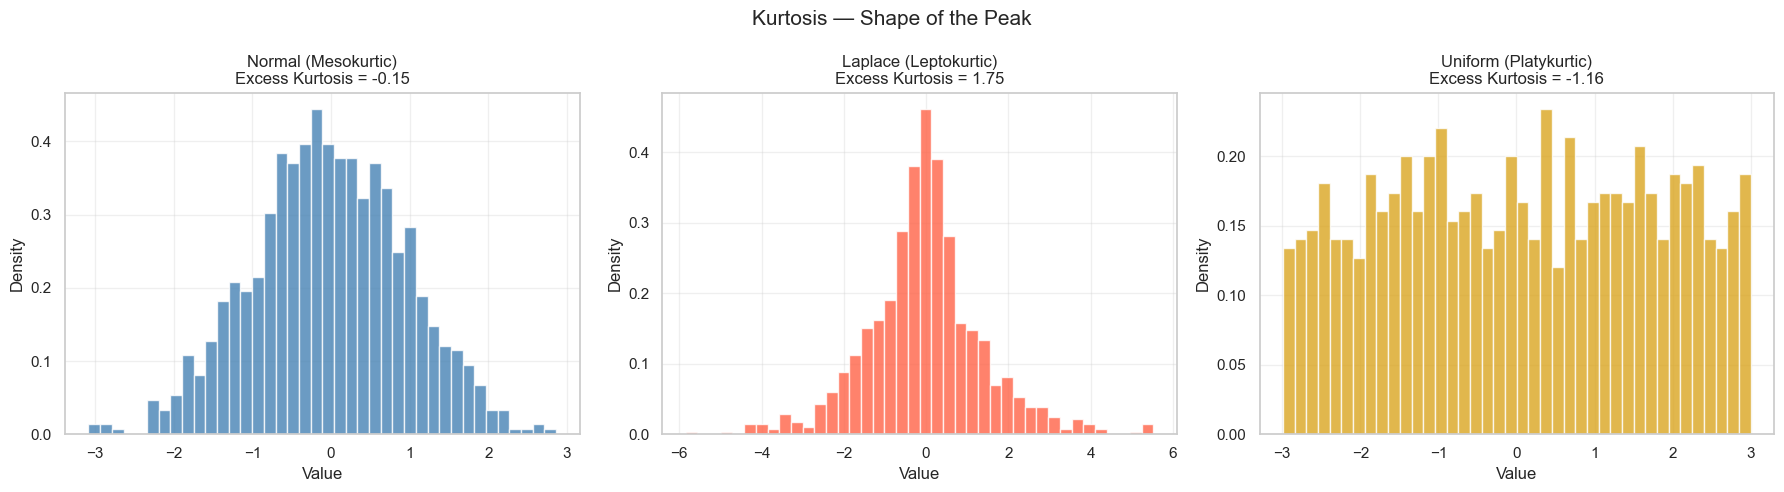

Skewness and Kurtosis Summary:
Distribution            Skewness  Excess Kurtosis  Shape
----------------------------------------------------------------------
Normal                    -0.046           -0.147  Flat peak
Laplace                    0.165            1.750  Sharp peak
Uniform                   -0.016           -1.164  Flat peak


In [13]:
np.random.seed(7)
normal_dist = np.random.normal(0, 1, 1000)           # Mesokurtic
lepto_dist  = np.random.laplace(0, 1, 1000)          # Leptokurtic (sharp peak)
platy_dist  = np.random.uniform(-3, 3, 1000)         # Platykurtic (flat)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, label, color in [
    (axes[0], normal_dist, 'Normal (Mesokurtic)', 'steelblue'),
    (axes[1], lepto_dist,  'Laplace (Leptokurtic)', 'tomato'),
    (axes[2], platy_dist,  'Uniform (Platykurtic)', 'goldenrod'),
]:
    kurt_val = stats.kurtosis(data)   # excess kurtosis
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.8, density=True)
    ax.set_title(f'{label}\nExcess Kurtosis = {kurt_val:.2f}', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

plt.suptitle('Kurtosis — Shape of the Peak', fontsize=15)
plt.tight_layout()
plt.show()

print('Skewness and Kurtosis Summary:')
print(f"{'Distribution':20s}  {'Skewness':>10s}  {'Excess Kurtosis':>15s}  {'Shape'}")
print('-' * 70)
for name, d in [('Normal', normal_dist), ('Laplace', lepto_dist), ('Uniform', platy_dist)]:
    sk = stats.skew(d)
    ku = stats.kurtosis(d)
    shape = 'Sharp peak' if ku > 0 else ('Flat peak' if ku < 0 else 'Normal peak')
    print(f'{name:20s}  {sk:>10.3f}  {ku:>15.3f}  {shape}')

---
## 6. Probability Basics

**Probability** = How likely is an event to happen?

```
P(Event) = Favourable Outcomes / Total Outcomes
Range: 0 ≤ P ≤ 1   (0 = impossible, 1 = certain)
```

### Key Rules:
| Rule | Formula | Example |
|------|---------|---------|
| Complement | P(not A) = 1 − P(A) | P(not rain) = 1 − P(rain) |
| Addition (OR) | P(A or B) = P(A) + P(B) − P(A and B) | P(King or Heart) |
| Multiplication (AND, independent) | P(A and B) = P(A) × P(B) | P(Head AND Head) |
| Conditional | P(A\|B) = P(A and B) / P(B) | P(pass\|studied) |

### Types of Events:
- **Independent** → Tossing a coin twice (first toss doesn't affect second)
- **Dependent** → Drawing cards without replacement
- **Mutually Exclusive** → Rolling a 3 OR a 5 on a die (can't be both)

In [14]:
# ── Basic Probability with Dice ──────────────────────────────────────────────
total_outcomes = 6
print('=== Dice Probability ===')
print(f'P(rolling a 4)         = 1/6 = {1/6:.4f}')
print(f'P(rolling even)        = 3/6 = {3/6:.4f}')
print(f'P(NOT rolling a 6)     = 5/6 = {5/6:.4f}  [Complement rule]')
print(f'P(rolling 2 OR 5)      = 2/6 = {2/6:.4f}  [Mutually exclusive: just add]')

print('\n=== Coin Toss ===')
print(f'P(Head)                = 0.5')
print(f'P(Head AND Head twice) = 0.5 × 0.5 = {0.5*0.5:.4f}  [Multiplication rule, independent]')
print(f'P(at least 1 Head in 2 tosses) = 1 - P(TT) = {1 - 0.5*0.5:.4f}  [Complement]')

# ── Simulation to Verify ──────────────────────────────────────────────────────
print('\n=== Simulation: Rolling a die 10,000 times ===')
np.random.seed(0)
rolls = np.random.randint(1, 7, 10000)
for face in [1, 2, 3, 4, 5, 6]:
    freq = np.sum(rolls == face)
    print(f'  Face {face}: {freq:5d} times → P = {freq/10000:.4f}  (theory: {1/6:.4f})')

# ── Conditional Probability ───────────────────────────────────────────────────
print('\n=== Conditional Probability: Exam Example ===')
# 100 students: 60 studied, 40 did not
# Of 60 who studied: 50 passed; Of 40 who did not: 10 passed
studied_and_passed   = 50
studied_total        = 60
P_studied            = studied_total / 100
P_studied_and_passed = studied_and_passed / 100
P_pass_given_studied = P_studied_and_passed / P_studied
print(f'P(studied)              = {P_studied:.2f}')
print(f'P(studied AND passed)   = {P_studied_and_passed:.2f}')
print(f'P(pass | studied)       = {P_pass_given_studied:.2f}  [P(A∩B)/P(B)]')
print(f'\nIf you studied → {P_pass_given_studied*100:.0f}% chance of passing!')

=== Dice Probability ===
P(rolling a 4)         = 1/6 = 0.1667
P(rolling even)        = 3/6 = 0.5000
P(NOT rolling a 6)     = 5/6 = 0.8333  [Complement rule]
P(rolling 2 OR 5)      = 2/6 = 0.3333  [Mutually exclusive: just add]

=== Coin Toss ===
P(Head)                = 0.5
P(Head AND Head twice) = 0.5 × 0.5 = 0.2500  [Multiplication rule, independent]
P(at least 1 Head in 2 tosses) = 1 - P(TT) = 0.7500  [Complement]

=== Simulation: Rolling a die 10,000 times ===
  Face 1:  1669 times → P = 0.1669  (theory: 0.1667)
  Face 2:  1714 times → P = 0.1714  (theory: 0.1667)
  Face 3:  1601 times → P = 0.1601  (theory: 0.1667)
  Face 4:  1706 times → P = 0.1706  (theory: 0.1667)
  Face 5:  1645 times → P = 0.1645  (theory: 0.1667)
  Face 6:  1665 times → P = 0.1665  (theory: 0.1667)

=== Conditional Probability: Exam Example ===
P(studied)              = 0.60
P(studied AND passed)   = 0.50
P(pass | studied)       = 0.83  [P(A∩B)/P(B)]

If you studied → 83% chance of passing!


---
## 6B. Probability Distributions

A **probability distribution** tells us how likely each value is.

### Key Distributions:

| Distribution | Shape | Used For | Parameters |
|-------------|-------|----------|------------|
| **Uniform** | Flat | All outcomes equally likely | min, max |
| **Binomial** | Bell / Skewed | Count of successes in n trials | n, p |
| **Poisson** | Right-skewed | Count of events in fixed time | λ (lambda) |
| **Normal** | Bell curve | Natural measurements | μ, σ |
| **Exponential** | Right-skewed | Time between events | λ |

### Binomial Distribution:
- **n** = number of trials
- **p** = probability of success on each trial
- **k** = number of successes
- `P(X=k) = C(n,k) × p^k × (1-p)^(n-k)`
- Mean = n×p, Std Dev = √(n×p×(1-p))

### Poisson Distribution:
- **λ** = average number of events per interval
- `P(X=k) = (e^-λ × λ^k) / k!`
- Mean = λ, Variance = λ

=== Binomial Distribution: Exam Passing ===
n=10 students, p=0.7 (70% chance each passes)
Mean (expected passes) = n×p = 7.0
Std Dev                = √(n×p×(1-p)) = 1.45

P(exactly  0 pass) = 0.0000  
P(exactly  1 pass) = 0.0001  
P(exactly  2 pass) = 0.0014  
P(exactly  3 pass) = 0.0090  
P(exactly  4 pass) = 0.0368  ███
P(exactly  5 pass) = 0.1029  ██████████
P(exactly  6 pass) = 0.2001  ████████████████████
P(exactly  7 pass) = 0.2668  ██████████████████████████
P(exactly  8 pass) = 0.2335  ███████████████████████
P(exactly  9 pass) = 0.1211  ████████████
P(exactly 10 pass) = 0.0282  ██

=== Poisson Distribution: Customer Arrivals ===
λ = 5 customers/hour on average
Mean = λ = 5,  Variance = λ = 5

P(exactly  0 customers) = 0.0067  
P(exactly  1 customers) = 0.0337  ███
P(exactly  2 customers) = 0.0842  ████████
P(exactly  3 customers) = 0.1404  ██████████████
P(exactly  4 customers) = 0.1755  █████████████████
P(exactly  5 customers) = 0.1755  █████████████████
P(exactly  6 custome

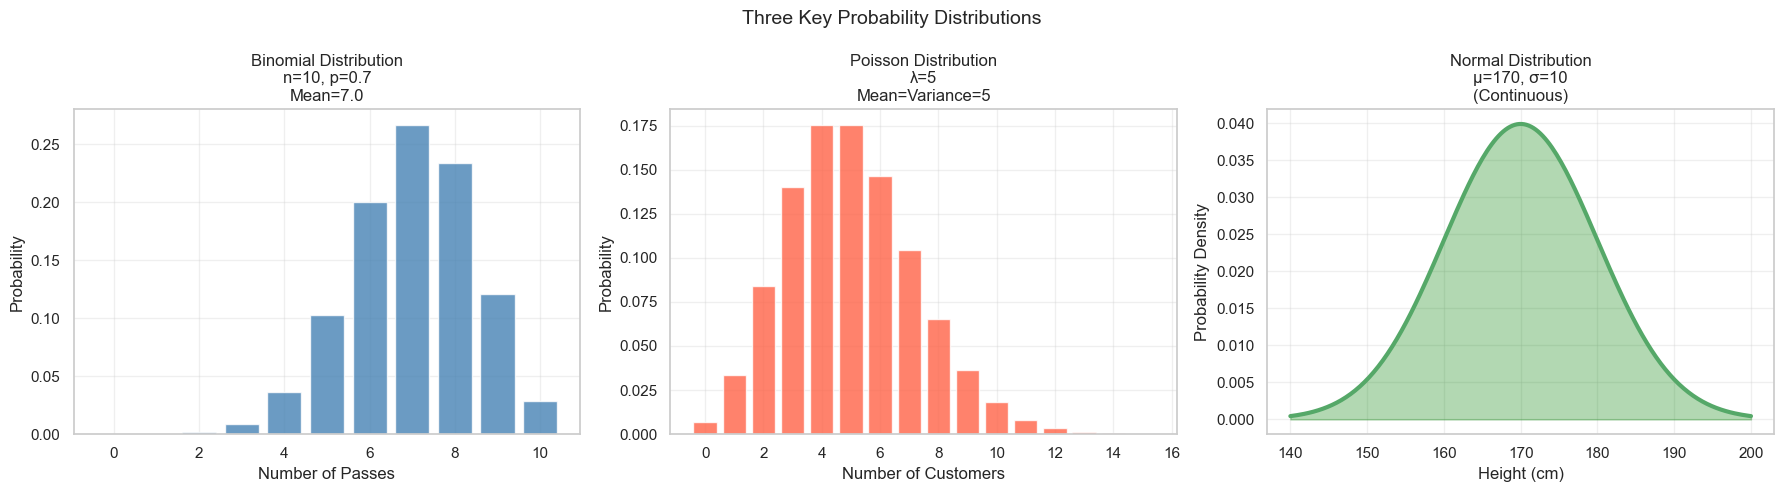

In [15]:
# ── Binomial Distribution ─────────────────────────────────────────────────────
# Example: 10 students, each has 70% chance of passing. How many will pass?
n, p = 10, 0.7
k_vals = np.arange(0, n+1)
binom_probs = binom.pmf(k_vals, n, p)

print('=== Binomial Distribution: Exam Passing ===')
print(f'n={n} students, p={p} (70% chance each passes)')
print(f'Mean (expected passes) = n×p = {n*p:.1f}')
print(f'Std Dev                = √(n×p×(1-p)) = {np.sqrt(n*p*(1-p)):.2f}')
print()
for k, prob in zip(k_vals, binom_probs):
    bar = '█' * int(prob * 100)
    print(f'P(exactly {k:2d} pass) = {prob:.4f}  {bar}')

# ── Poisson Distribution ──────────────────────────────────────────────────────
print('\n=== Poisson Distribution: Customer Arrivals ===')
lam = 5   # average 5 customers per hour
k_pois = np.arange(0, 16)
pois_probs = poisson.pmf(k_pois, lam)

print(f'λ = {lam} customers/hour on average')
print(f'Mean = λ = {lam},  Variance = λ = {lam}')
print()
for k, prob in zip(k_pois, pois_probs):
    bar = '█' * int(prob * 100)
    print(f'P(exactly {k:2d} customers) = {prob:.4f}  {bar}')

# ── Visual Comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Binomial
axes[0].bar(k_vals, binom_probs, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Binomial Distribution\nn={n}, p={p}\nMean={n*p}', fontsize=12)
axes[0].set_xlabel('Number of Passes')
axes[0].set_ylabel('Probability')
axes[0].grid(True, alpha=0.3)

# Poisson
axes[1].bar(k_pois, pois_probs, color='tomato', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Poisson Distribution\nλ={lam}\nMean=Variance={lam}', fontsize=12)
axes[1].set_xlabel('Number of Customers')
axes[1].set_ylabel('Probability')
axes[1].grid(True, alpha=0.3)

# Normal (for comparison)
x_norm = np.linspace(140, 200, 200)
axes[2].plot(x_norm, norm.pdf(x_norm, 170, 10), 'g-', lw=3)
axes[2].fill_between(x_norm, norm.pdf(x_norm, 170, 10), alpha=0.3, color='green')
axes[2].set_title(f'Normal Distribution\nμ=170, σ=10\n(Continuous)', fontsize=12)
axes[2].set_xlabel('Height (cm)')
axes[2].set_ylabel('Probability Density')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Three Key Probability Distributions', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6C. Bayes' Theorem

**The most important formula in Data Science and AI.**

```
P(A|B) = P(B|A) × P(A) / P(B)
```

In plain English:
- **P(A)** = Prior probability (what we believed before)
- **P(B|A)** = Likelihood (probability of evidence given hypothesis)
- **P(B)** = Marginal probability (total probability of evidence)
- **P(A|B)** = Posterior probability (updated belief after seeing evidence)

### Why is it important in DS/AI?
- Powers the **Naive Bayes classifier** (spam detection, sentiment analysis)
- Used in **medical diagnosis** (false positives/negatives)
- Foundation of **Bayesian statistics** and **probabilistic models**
- Used in **recommendation systems**

### Classic Example: Medical Test
A disease affects 1% of population. A test is 99% accurate.
If someone tests POSITIVE, what is the actual probability they have the disease?
(Answer is surprisingly low — this is why understanding Bayes is critical!)

=== Bayes Theorem: Medical Diagnosis ===
Disease prevalence in population   : 1.0%
Test sensitivity (detects disease) : 99%
Test false positive rate           : 1%

P(positive test)                   = 0.0198 (1.98%)

If you test POSITIVE:
P(actually have disease | positive) = 0.5000 (50.0%)

Surprising! Even with 99% accurate test, if you test positive,
there is only a 50.0% chance you actually have the disease.
This is because the disease is rare (1% prevalence).

=== Bayes Theorem: Spam Detection ===
P(spam)                   = 0.30
P("FREE" in spam email)   = 0.80
P("FREE" in legit email)  = 0.05

P(spam | email has "FREE") = 0.8727 = 87.3%

Conclusion: An email with the word "FREE" has 87% chance of being spam.
This is exactly how Naive Bayes spam filter works!


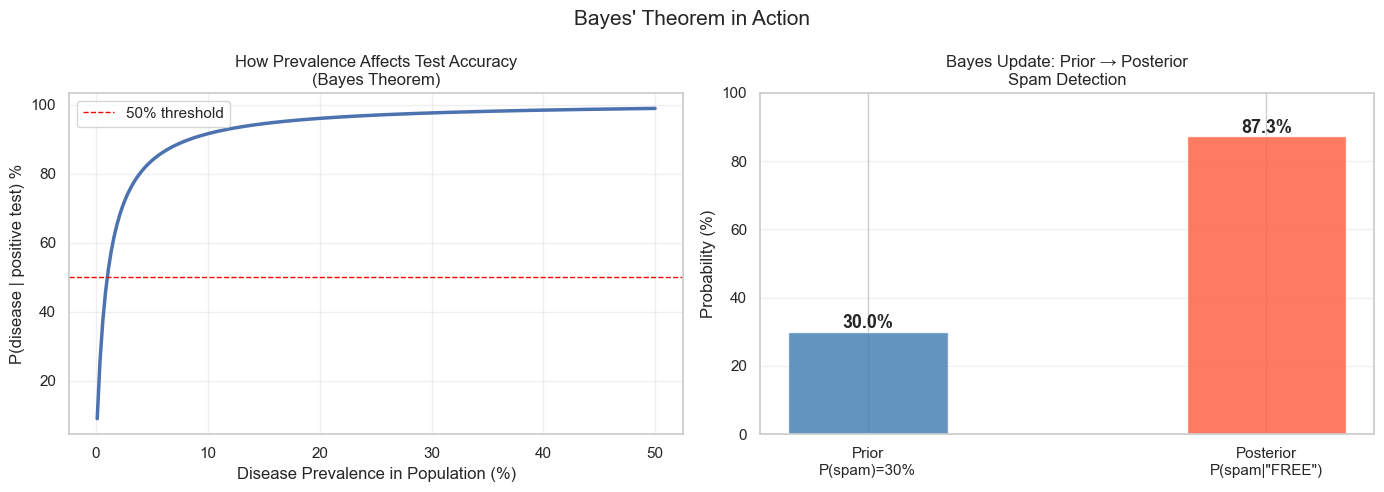

In [16]:
# ── Medical Test: Bayes' Theorem ──────────────────────────────────────────────
P_disease       = 0.01    # 1% of population has the disease
P_no_disease    = 1 - P_disease

P_pos_given_disease    = 0.99  # test correctly detects disease 99% (sensitivity)
P_pos_given_no_disease = 0.01  # false positive rate 1% (1 - specificity)

# P(positive) = total chance of testing positive
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Bayes' Theorem: P(disease | positive)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print('=== Bayes Theorem: Medical Diagnosis ===')
print(f'Disease prevalence in population   : {P_disease*100:.1f}%')
print(f'Test sensitivity (detects disease) : {P_pos_given_disease*100:.0f}%')
print(f'Test false positive rate           : {P_pos_given_no_disease*100:.0f}%')
print(f'\nP(positive test)                   = {P_positive:.4f} ({P_positive*100:.2f}%)')
print(f'\nIf you test POSITIVE:')
print(f'P(actually have disease | positive) = {P_disease_given_pos:.4f} ({P_disease_given_pos*100:.1f}%)')
print(f'\nSurprising! Even with 99% accurate test, if you test positive,')
print(f'there is only a {P_disease_given_pos*100:.1f}% chance you actually have the disease.')
print(f'This is because the disease is rare (1% prevalence).')

# ── Email Spam Detection Example ──────────────────────────────────────────────
print('\n=== Bayes Theorem: Spam Detection ===')
P_spam         = 0.30    # 30% of emails are spam
P_ham          = 0.70    # 70% are legitimate

P_word_spam    = 0.80    # word "FREE" appears in 80% of spam emails
P_word_ham     = 0.05    # word "FREE" appears in 5% of legit emails

P_word         = P_word_spam * P_spam + P_word_ham * P_ham
P_spam_given_word = (P_word_spam * P_spam) / P_word

print(f'P(spam)                   = {P_spam:.2f}')
print(f'P("FREE" in spam email)   = {P_word_spam:.2f}')
print(f'P("FREE" in legit email)  = {P_word_ham:.2f}')
print(f'\nP(spam | email has "FREE") = {P_spam_given_word:.4f} = {P_spam_given_word*100:.1f}%')
print(f'\nConclusion: An email with the word "FREE" has {P_spam_given_word*100:.0f}% chance of being spam.')
print('This is exactly how Naive Bayes spam filter works!')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Medical test visualization
prevalences = np.linspace(0.001, 0.5, 200)
posteriors  = [(0.99 * p) / (0.99 * p + 0.01 * (1-p)) for p in prevalences]
axes[0].plot(prevalences * 100, [p*100 for p in posteriors], 'b-', lw=2.5)
axes[0].axhline(50, color='red', linestyle='--', lw=1, label='50% threshold')
axes[0].set_xlabel('Disease Prevalence in Population (%)')
axes[0].set_ylabel('P(disease | positive test) %')
axes[0].set_title('How Prevalence Affects Test Accuracy\n(Bayes Theorem)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prior vs Posterior
labels = ['Prior\nP(spam)=30%', 'Posterior\nP(spam|"FREE")']
values = [P_spam * 100, P_spam_given_word * 100]
colors = ['steelblue', 'tomato']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.4, alpha=0.85)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Probability (%)')
axes[1].set_title('Bayes Update: Prior → Posterior\nSpam Detection', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Bayes' Theorem in Action", fontsize=15)
plt.tight_layout()
plt.show()

---
## 5. Percentiles and Quartiles

In [17]:
salaries = np.random.normal(60000, 15000, 1000).astype(int)

percentiles = [10, 25, 50, 75, 90, 95, 99]
print('Salary Percentiles:')
for p in percentiles:
    value = np.percentile(salaries, p)
    print(f'  {p:>3}th percentile = Rs {value:>8,}')

print(f'\nIf your salary is Rs 75,000:')
your_salary = 75000
your_percentile = stats.percentileofscore(salaries, your_salary)
print(f'You are at the {your_percentile:.1f}th percentile')
print(f'You earn more than {your_percentile:.1f}% of employees')

Salary Percentiles:
   10th percentile = Rs 38,632.5
   25th percentile = Rs 49,414.0
   50th percentile = Rs 60,530.0
   75th percentile = Rs 70,933.25
   90th percentile = Rs 80,330.9
   95th percentile = Rs 85,124.45
   99th percentile = Rs 96,567.32999999997

If your salary is Rs 75,000:
You are at the 83.3th percentile
You earn more than 83.3% of employees


---
## 6. Normal Distribution (Bell Curve)

Most important distribution in statistics.

**Empirical Rule (68-95-99.7):**
- 68% of data falls within 1 standard deviation of mean
- 95% within 2 standard deviations
- 99.7% within 3 standard deviations

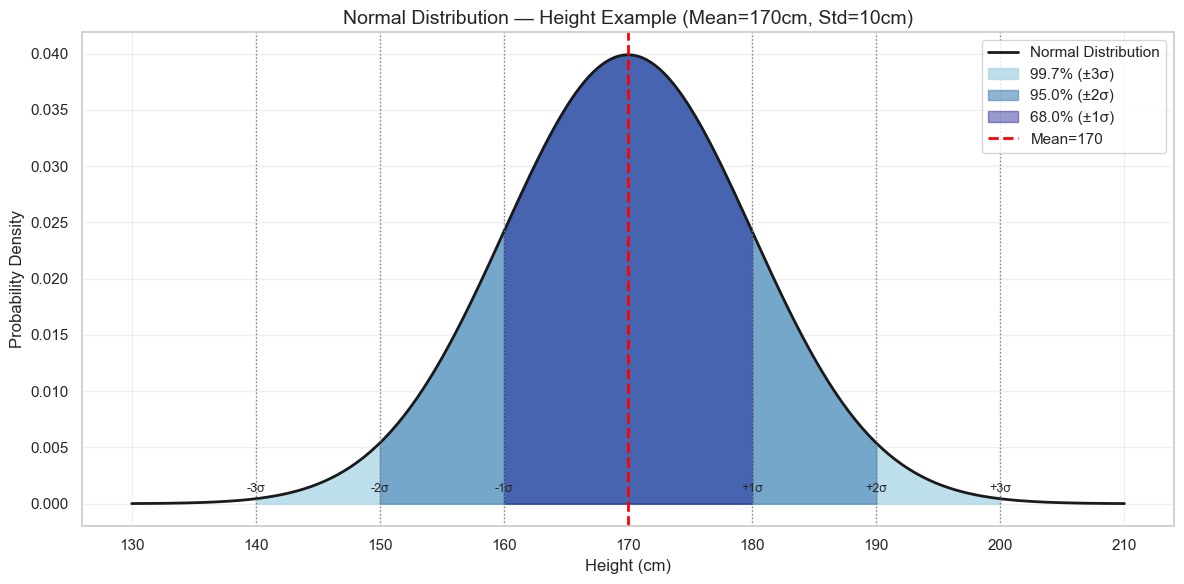

In [18]:
mu, sigma = 170, 10  # Height: mean=170cm, std=10cm
x = np.linspace(130, 210, 300)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'k-', linewidth=2, label='Normal Distribution')

# Shade regions
for n_std, color, alpha, label in [
    (3, 'lightblue',  0.8, '99.7% (±3σ)'),
    (2, 'steelblue',  0.6, '95.0% (±2σ)'),
    (1, 'darkblue',   0.4, '68.0% (±1σ)')
]:
    x_fill = np.linspace(mu - n_std*sigma, mu + n_std*sigma, 200)
    ax.fill_between(x_fill, norm.pdf(x_fill, mu, sigma), alpha=alpha, color=color, label=label)

ax.axvline(mu, color='red', linestyle='--', lw=2, label=f'Mean={mu}')
for n in [1, 2, 3]:
    ax.axvline(mu + n*sigma, color='gray', linestyle=':', lw=1)
    ax.axvline(mu - n*sigma, color='gray', linestyle=':', lw=1)
    ax.text(mu + n*sigma, 0.001, f'+{n}σ', ha='center', fontsize=9)
    ax.text(mu - n*sigma, 0.001, f'-{n}σ', ha='center', fontsize=9)

ax.set_title('Normal Distribution — Height Example (Mean=170cm, Std=10cm)', fontsize=14)
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8B. Central Limit Theorem (CLT)

**The single most important theorem in all of statistics.**

> *"If you take many random samples from ANY distribution and compute the sample mean, those sample means will form a NORMAL distribution — regardless of what the original data looked like."*

### The Rule:
- Population can be skewed, uniform, bimodal — doesn't matter
- Take samples of size n ≥ 30
- Sample means → follow Normal distribution
- Mean of sample means ≈ Population mean
- Std of sample means = σ / √n (called **Standard Error**)

### Why does this matter in DS/AI?
- Allows us to use t-tests, confidence intervals on ANY data
- Justifies why so many ML algorithms assume normality
- Foundation of all statistical inference

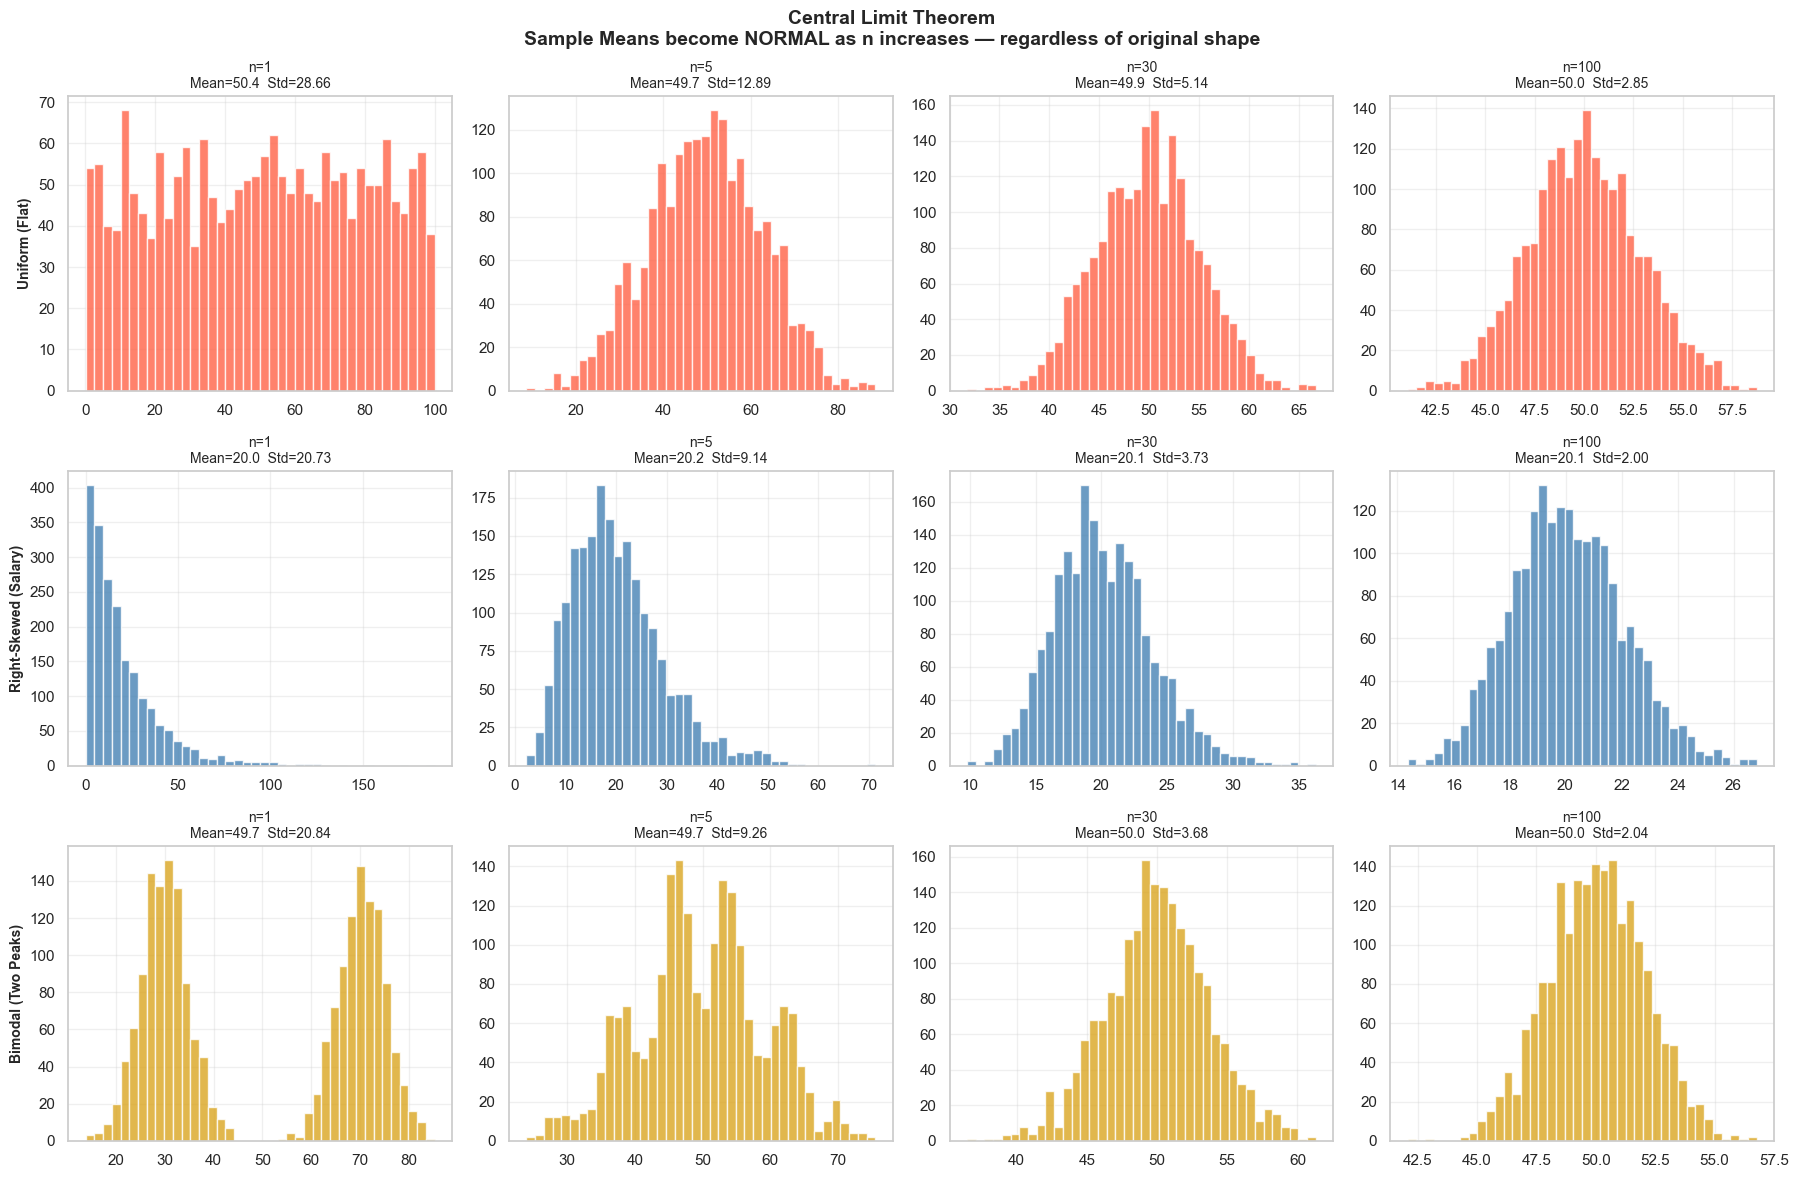

=== Central Limit Theorem: Key Insight ===
Original Population:  Mean=20.09  Std=20.14  (right-skewed)
Sample means (n=  5):  Mean=20.11  Std=9.11  (theory SE=9.01)  → Not yet normal
Sample means (n= 30):  Mean=20.08  Std=3.66  (theory SE=3.68)  → Normal!
Sample means (n=100):  Mean=20.07  Std=2.03  (theory SE=2.01)  → Normal!


In [19]:
np.random.seed(42)

# Three very different population shapes
populations = {
    'Uniform (Flat)':        np.random.uniform(0, 100, 100000),
    'Right-Skewed (Salary)': np.random.exponential(20, 100000),
    'Bimodal (Two Peaks)':   np.concatenate([np.random.normal(30,5,50000),
                                              np.random.normal(70,5,50000)])
}

sample_sizes = [1, 5, 30, 100]
fig, axes = plt.subplots(len(populations), len(sample_sizes), figsize=(18, 12))

for row, (pop_name, pop_data) in enumerate(populations.items()):
    for col, n in enumerate(sample_sizes):
        # Draw 2000 samples of size n, compute means
        sample_means = [np.mean(np.random.choice(pop_data, n, replace=False))
                        for _ in range(2000)]
        axes[row, col].hist(sample_means, bins=40, edgecolor='white', alpha=0.8,
                            color=['tomato','steelblue','goldenrod'][row])
        axes[row, col].set_title(f'n={n}\nMean={np.mean(sample_means):.1f}  Std={np.std(sample_means):.2f}',
                                  fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(pop_name, fontsize=10, fontweight='bold')
        axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Central Limit Theorem\nSample Means become NORMAL as n increases — regardless of original shape',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key numbers
print('=== Central Limit Theorem: Key Insight ===')
pop = np.random.exponential(20, 100000)
print(f'Original Population:  Mean={pop.mean():.2f}  Std={pop.std():.2f}  (right-skewed)')
for n in [5, 30, 100]:
    means = [np.mean(np.random.choice(pop, n)) for _ in range(5000)]
    theoretical_se = pop.std() / np.sqrt(n)
    print(f'Sample means (n={n:3d}):  Mean={np.mean(means):.2f}  Std={np.std(means):.2f}  '
          f'(theory SE={theoretical_se:.2f})  → {"Normal!" if n>=30 else "Not yet normal"}')

---
## 7. Z-Score (Standardization)

**Z-score tells you how many standard deviations a value is from the mean.**

Formula: `Z = (X - mean) / std`

In [20]:
# Class test scores
scores = np.array([55, 70, 82, 65, 90, 78, 48, 88, 72, 60])

mean_score = np.mean(scores)
std_score  = np.std(scores)
z_scores   = (scores - mean_score) / std_score

df_z = pd.DataFrame({
    'Score': scores,
    'Z-Score': z_scores.round(2),
    'Interpretation': []
})

interp = []
for z in z_scores:
    if z > 2: interp.append('Very High (above 95%)')
    elif z > 1: interp.append('High (above 84%)')
    elif z > 0: interp.append('Above Average')
    elif z > -1: interp.append('Below Average')
    elif z > -2: interp.append('Low (below 16%)')
    else: interp.append('Very Low (below 2%)')

df_z['Interpretation'] = interp
print(f'Mean = {mean_score:.1f}, Std Dev = {std_score:.2f}')
print()
print(df_z)

print(f'\nThe student who scored 90:')
z = (90 - mean_score) / std_score
print(f'  Z-score = {z:.2f}')
print(f'  They scored better than {norm.cdf(z)*100:.1f}% of the class')

ValueError: All arrays must be of the same length

---
## 10. Outlier Detection

**An outlier** is a data point that is far away from the rest of the data. It can distort your analysis.

Two most common methods:
1. **Z-Score Method** → Flag values with |Z| > 3
2. **IQR Method (Tukey's Fence)** → Flag values outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]

> **IQR method is preferred** for skewed data; Z-score method works better for normal distributions.

In [ ]:
np.random.seed(42)
salaries = np.concatenate([
    np.random.normal(55000, 8000, 95),      # normal employees
    [200000, 250000, 300000, 5000, 8000]    # CEO + interns (outliers)
])

# ── Method 1: Z-Score ─────────────────────────────────────────────────────────
z_scores      = (salaries - salaries.mean()) / salaries.std()
outliers_z    = salaries[np.abs(z_scores) > 3]

# ── Method 2: IQR ─────────────────────────────────────────────────────────────
Q1            = np.percentile(salaries, 25)
Q3            = np.percentile(salaries, 75)
IQR_val       = Q3 - Q1
lower_fence   = Q1 - 1.5 * IQR_val
upper_fence   = Q3 + 1.5 * IQR_val
outliers_iqr  = salaries[(salaries < lower_fence) | (salaries > upper_fence)]

print('=== Outlier Detection: Salary Data ===')
print(f'Total records       : {len(salaries)}')
print(f'Mean salary         : Rs {salaries.mean():>10,.0f}')
print(f'Median salary       : Rs {np.median(salaries):>10,.0f}')

print(f'\n--- Z-Score Method (|Z| > 3) ---')
print(f'Lower / Upper limit : ±3 standard deviations from mean')
print(f'Outliers found      : {len(outliers_z)}')
print(f'Outlier values      : {sorted(outliers_z.astype(int))}')

print(f'\n--- IQR Method (Tukey Fence) ---')
print(f'Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR_val:,.0f}')
print(f'Lower fence = Q1 − 1.5×IQR = {lower_fence:,.0f}')
print(f'Upper fence = Q3 + 1.5×IQR = {upper_fence:,.0f}')
print(f'Outliers found      : {len(outliers_iqr)}')
print(f'Outlier values      : {sorted(outliers_iqr.astype(int))}')

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(range(len(salaries)), np.sort(salaries), color='steelblue', s=30, alpha=0.6)
axes[0].axhline(upper_fence, color='red',    linestyle='--', lw=2, label=f'Upper fence: {upper_fence:,.0f}')
axes[0].axhline(lower_fence, color='orange', linestyle='--', lw=2, label=f'Lower fence: {lower_fence:,.0f}')
axes[0].set_title('IQR Outlier Detection', fontsize=13)
axes[0].set_ylabel('Salary (Rs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(len(salaries)), np.abs(z_scores[np.argsort(salaries)]),
                color='tomato', s=30, alpha=0.6)
axes[1].axhline(3, color='red', linestyle='--', lw=2, label='Z = 3 threshold')
axes[1].set_title('Z-Score Outlier Detection', fontsize=13)
axes[1].set_ylabel('|Z-Score|')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Outlier Detection: IQR vs Z-Score', fontsize=14)
plt.tight_layout()
plt.show()

---
## 10B. Normality Testing

**Before applying t-test, ANOVA, or any parametric test — you MUST check if your data is normally distributed.**

### Methods:
1. **Histogram + Skewness/Kurtosis** — Visual quick check
2. **Shapiro-Wilk Test** — Best for small samples (n < 2000)
   - H0: Data is normally distributed
   - p > 0.05 → Data IS normal (cannot reject H0)
   - p < 0.05 → Data is NOT normal
3. **Q-Q Plot (Quantile-Quantile Plot)** — Points follow the diagonal line if normal

### What to do if data is NOT normal?
- Use **non-parametric tests** (Mann-Whitney instead of t-test; Kruskal-Wallis instead of ANOVA)
- Apply **log transformation** (common for right-skewed data like salaries)
- Collect more data (CLT kicks in at n ≥ 30)

In [ ]:
np.random.seed(42)
normal_data  = np.random.normal(70, 10, 100)
skewed_data  = np.random.exponential(20, 100) + 30

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (data, label, color) in enumerate([
    (normal_data, 'Normal Data',  'steelblue'),
    (skewed_data, 'Skewed Data',  'tomato')
]):
    sw_stat, sw_p = shapiro(data)
    skewness = stats.skew(data)
    kurt_val  = stats.kurtosis(data)

    # Histogram
    axes[row, 0].hist(data, bins=20, color=color, edgecolor='white', alpha=0.8)
    axes[row, 0].set_title(f'{label}\nSkew={skewness:.2f}  Kurtosis={kurt_val:.2f}', fontsize=12)
    axes[row, 0].set_xlabel('Value')
    axes[row, 0].grid(True, alpha=0.3)

    # Q-Q Plot
    (osm, osr), (slope, intercept, r) = probplot(data, dist='norm')
    axes[row, 1].scatter(osm, osr, color=color, s=20, alpha=0.7)
    axes[row, 1].plot(osm, slope*np.array(osm) + intercept, 'k-', lw=2, label='Reference line')
    axes[row, 1].set_title(f'Q-Q Plot\n{"Points follow line → NORMAL" if sw_p > 0.05 else "Points deviate → NOT NORMAL"}',
                            fontsize=12)
    axes[row, 1].set_xlabel('Theoretical Quantiles')
    axes[row, 1].set_ylabel('Sample Quantiles')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

    # Shapiro-Wilk result
    axes[row, 2].text(0.5, 0.6, f'Shapiro-Wilk Test\n\nW = {sw_stat:.4f}\np = {sw_p:.4f}\n\n'
                      + ('p > 0.05\n→ NORMAL ✓' if sw_p > 0.05 else 'p < 0.05\n→ NOT NORMAL ✗'),
                      ha='center', va='center', fontsize=14, transform=axes[row, 2].transAxes,
                      bbox=dict(boxstyle='round', facecolor='lightgreen' if sw_p > 0.05 else 'lightsalmon',
                                alpha=0.8))
    axes[row, 2].axis('off')

plt.suptitle('Normality Testing: Histogram + Q-Q Plot + Shapiro-Wilk', fontsize=14)
plt.tight_layout()
plt.show()

# Log transformation for skewed data
print('=== Log Transformation ===')
print(f'Original skewed data: Skewness={stats.skew(skewed_data):.2f}  (NOT normal)')
log_data = np.log(skewed_data)
print(f'After log transform:  Skewness={stats.skew(log_data):.2f}  (much closer to normal!)')
_, p_log = shapiro(log_data)
print(f'Shapiro-Wilk after log transform: p={p_log:.4f}  → {"Normal" if p_log > 0.05 else "Not normal"}')

---
## 11. Covariance

**Covariance** measures whether two variables move in the same direction.

```
Cov(X, Y) > 0 → X and Y increase together  (positive relationship)
Cov(X, Y) < 0 → X increases, Y decreases  (negative relationship)
Cov(X, Y) = 0 → No linear relationship
```

**Problem with covariance:** The value depends on the units of measurement.
- Cov(hours, marks) is in "hours × marks" — hard to interpret!
- That's why we normalize it → **Correlation**

In [ ]:
np.random.seed(42)
hours  = np.random.uniform(1, 10, 50)
marks  = 40 + hours * 5 + np.random.normal(0, 4, 50)
temp   = np.random.uniform(25, 42, 50)
icecream = 20 + temp * 3 + np.random.normal(0, 5, 50)

cov_matrix = np.cov(hours, marks)
print('=== Covariance Examples ===')
print(f'\nHours studied vs Marks:')
print(f'  Cov(hours, marks) = {cov_matrix[0,1]:.2f}  → POSITIVE (more hours = more marks)')

cov_matrix2 = np.cov(temp, icecream)
print(f'\nTemperature vs Ice cream sales:')
print(f'  Cov(temp, sales)  = {cov_matrix2[0,1]:.2f}  → POSITIVE (hotter = more sales)')

# Negative example
price  = np.random.uniform(100, 1000, 50)
demand = 1000 - price * 0.8 + np.random.normal(0, 50, 50)
cov_neg = np.cov(price, demand)
print(f'\nProduct price vs Demand:')
print(f'  Cov(price, demand) = {cov_neg[0,1]:.2f}  → NEGATIVE (higher price = lower demand)')

print('\n--- Covariance Matrix ---')
df_cov = pd.DataFrame({'Hours': hours, 'Marks': marks})
print(df_cov.cov().round(2))
print('\nInterpretation: Diagonal = variance of each variable; Off-diagonal = covariance between variables')

In [ ]:
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 80)
exam_score    = 40 + hours_studied * 5 + np.random.normal(0, 5, 80)

pearson_r,  p_pearson  = stats.pearsonr(hours_studied, exam_score)
spearman_r, p_spearman = stats.spearmanr(hours_studied, exam_score)

print('=== Correlation: Study Hours vs Exam Score ===')
print(f'\nPearson  r = {pearson_r:.4f}  (p = {p_pearson:.6f})')
print(f'Spearman r = {spearman_r:.4f}  (p = {p_spearman:.6f})')

print('\nPearson vs Spearman:')
print('  Pearson  → Linear relationship, assumes normal data, sensitive to outliers')
print('  Spearman → Rank-based (monotonic), works with non-normal data, robust to outliers')

strength = lambda r: 'Very Strong' if abs(r)>0.9 else ('Strong' if abs(r)>0.7 else ('Moderate' if abs(r)>0.4 else 'Weak'))
direction = lambda r: 'Positive' if r > 0 else 'Negative'
print(f'\nConclusion: {strength(pearson_r)} {direction(pearson_r)} correlation (r = {pearson_r:.2f})')
if p_pearson < 0.05:
    print('Statistically SIGNIFICANT (p < 0.05)')

# ── Scatter + regression line ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r_val, label in [(axes[0], pearson_r, 'Pearson'), (axes[1], spearman_r, 'Spearman')]:
    ax.scatter(hours_studied, exam_score, alpha=0.6, color='steelblue', s=60)
    z = np.polyfit(hours_studied, exam_score, 1)
    p_fit = np.poly1d(z)
    x_line = np.sort(hours_studied)
    ax.plot(x_line, p_fit(x_line), 'r-', lw=2, label=f'{label} r = {r_val:.2f}')
    ax.set_title(f'{label} Correlation', fontsize=13)
    ax.set_xlabel('Hours Studied')
    ax.set_ylabel('Exam Score')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle('Pearson vs Spearman Correlation', fontsize=15)
plt.tight_layout()
plt.show()

# ── Correlation Heatmap ───────────────────────────────────────────────────────
df_corr = pd.DataFrame({
    'Study Hours': hours_studied,
    'Exam Score' : exam_score,
    'Sleep Hours': np.random.uniform(4, 9, 80),
    'Phone Time' : np.random.uniform(1, 8, 80)
})
plt.figure(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

---
## 12B. Simple Linear Regression — Statistics View

**Regression finds the best-fit line through data.**

`Y = β0 + β1×X + ε`
- **β0** = intercept (Y when X=0)
- **β1** = slope (how much Y changes per unit X)
- **ε** = error (residual)

### Key Metrics:
| Metric | Formula | Meaning |
|--------|---------|---------|
| **R²** (R-squared) | 1 - SS_res/SS_tot | % of variance explained by the model |
| **Adjusted R²** | Penalizes adding useless features | Used for multiple regression |
| **RMSE** | √(mean of squared errors) | Average prediction error (same unit as Y) |
| **MAE** | Mean of |actual - predicted| | Average absolute error |
| **p-value of slope** | From t-test | Is the relationship statistically significant? |

### R² Interpretation:
- R² = 0.90 → The model explains 90% of the variation in Y
- R² = 0.10 → The model explains only 10% (poor fit)
- R² = 1.00 → Perfect fit (usually means overfitting!)

In [ ]:
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 80)
exam_marks  = 30 + 6 * study_hours + np.random.normal(0, 8, 80)

# Fit linear regression using scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(study_hours, exam_marks)

# Predictions and errors
predicted = intercept + slope * study_hours
residuals = exam_marks - predicted

r_squared = r_value ** 2
rmse = np.sqrt(np.mean(residuals ** 2))
mae  = np.mean(np.abs(residuals))

print('=== Simple Linear Regression: Study Hours → Exam Marks ===')
print(f'\nModel:  Marks = {intercept:.2f} + {slope:.2f} × Hours')
print(f'\nIntercept (β0) = {intercept:.2f}  → Expected score with 0 hours study')
print(f'Slope     (β1) = {slope:.2f}  → Each extra study hour adds {slope:.2f} marks')
print(f'\n--- Model Performance ---')
print(f'R²      = {r_squared:.4f}  → Model explains {r_squared*100:.1f}% of score variation')
print(f'RMSE    = {rmse:.2f}  → Average prediction error = {rmse:.1f} marks')
print(f'MAE     = {mae:.2f}  → Average absolute error = {mae:.1f} marks')
print(f'r       = {r_value:.4f}  → Pearson correlation')
print(f'p-value = {p_value:.6f}  → {"SIGNIFICANT: Slope is not zero" if p_value<0.05 else "Not significant"}')

# Prediction example
for h in [3, 6, 9]:
    pred = intercept + slope * h
    print(f'Prediction: {h} hours of study → Expected score = {pred:.1f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter + regression line
x_line = np.linspace(study_hours.min(), study_hours.max(), 100)
y_line = intercept + slope * x_line
axes[0].scatter(study_hours, exam_marks, color='steelblue', alpha=0.6, s=50, label='Data')
axes[0].plot(x_line, y_line, 'r-', lw=2.5, label=f'Y = {intercept:.1f} + {slope:.1f}X\nR²={r_squared:.3f}')
axes[0].set_title('Linear Regression Fit', fontsize=13)
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Exam Marks')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot (should be random scatter — no pattern)
axes[1].scatter(predicted, residuals, color='tomato', alpha=0.6, s=50)
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Plot\n(Should be random — no pattern)', fontsize=13)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, alpha=0.3)

# R² comparison: good vs poor fit
np.random.seed(1)
x_test = np.random.uniform(0, 10, 60)
good_fit = 2*x_test + np.random.normal(0, 1, 60)
poor_fit = 2*x_test + np.random.normal(0, 8, 60)

for data, label, color in [(good_fit, 'Good fit', 'steelblue'), (poor_fit, 'Poor fit', 'tomato')]:
    sl, ic, rv, _, _ = stats.linregress(x_test, data)
    axes[2].scatter(x_test, data, color=color, alpha=0.4, s=30, label=f'{label} R²={rv**2:.2f}')
    axes[2].plot(np.sort(x_test), ic + sl*np.sort(x_test), color=color, lw=2)

axes[2].set_title('R² Comparison: Good vs Poor Fit', fontsize=13)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Simple Linear Regression — Statistics Interpretation', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Hypothesis Testing

**Hypothesis testing answers: Is the difference real or just by chance?**

```
H0 (Null Hypothesis)      = No difference / No effect
H1 (Alternative Hypothesis) = There IS a difference

If p-value < 0.05 → Reject H0 (difference is real)
If p-value >= 0.05 → Cannot reject H0
```

In [ ]:
# T-Test: Do two groups have the same mean?
# Question: Is there a significant salary difference between IT and HR?
np.random.seed(42)
it_salary  = np.random.normal(85000, 12000, 50)
hr_salary  = np.random.normal(65000, 10000, 50)

print('IT Department:', f'Mean = Rs {it_salary.mean():,.0f}, Std = Rs {it_salary.std():,.0f}')
print('HR Department:', f'Mean = Rs {hr_salary.mean():,.0f}, Std = Rs {hr_salary.std():,.0f}')

t_stat, p_value = ttest_ind(it_salary, hr_salary)
print(f'\nTwo-Sample T-Test:')
print(f'  t-statistic = {t_stat:.4f}')
print(f'  p-value     = {p_value:.6f}')

if p_value < 0.05:
    print(f'\nResult: p < 0.05 → REJECT H0')
    print('Conclusion: Salary difference between IT and HR is STATISTICALLY SIGNIFICANT.')
else:
    print(f'\nResult: p >= 0.05 → CANNOT reject H0')
    print('Conclusion: No significant salary difference found.')

In [ ]:
# Chi-Square Test: Are two categorical variables related?
# Question: Is there a relationship between department and performance?

contingency = pd.DataFrame({
    'Excellent': [20, 10, 15],
    'Good':      [25, 20, 20],
    'Average':   [15, 25, 15],
    'Poor':      [ 5, 10,  5]
}, index=['IT', 'HR', 'Finance'])

print('Observed Frequency Table:')
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'\nChi-Square Test:')
print(f'  Chi2 statistic = {chi2:.4f}')
print(f'  p-value        = {p:.4f}')
print(f'  Degrees of freedom = {dof}')

if p < 0.05:
    print('\nResult: p < 0.05 → REJECT H0')
    print('Conclusion: Department and Performance are RELATED.')
else:
    print('\nResult: p >= 0.05 → Cannot reject H0')
    print('Conclusion: No significant relationship found.')

---
## 14B. ANOVA — Analysis of Variance

**T-test compares 2 groups. ANOVA compares 3 or more groups.**

Why not just run multiple t-tests?
- If you run 10 t-tests at α=0.05, probability of at least one false positive = 1 - (0.95)^10 = **40%!**
- ANOVA controls this by testing all groups simultaneously.

```
H0: All group means are equal  (μ1 = μ2 = μ3)
H1: At least one group mean is different

If p < 0.05 → Reject H0 → At least one group is different
```

**F-statistic** = Variance between groups / Variance within groups
- High F → Groups are very different from each other → significant

In [ ]:
np.random.seed(42)

# Teaching method comparison: 3 groups
method_A = np.random.normal(72, 10, 40)   # Traditional lecture
method_B = np.random.normal(78, 10, 40)   # Video + lecture
method_C = np.random.normal(85, 10, 40)   # Project-based learning

print('=== ANOVA: Comparing 3 Teaching Methods ===')
print(f'Method A (Lecture):         Mean={method_A.mean():.1f}  Std={method_A.std():.1f}')
print(f'Method B (Video+Lecture):   Mean={method_B.mean():.1f}  Std={method_B.std():.1f}')
print(f'Method C (Project-based):   Mean={method_C.mean():.1f}  Std={method_C.std():.1f}')

f_stat, p_value = f_oneway(method_A, method_B, method_C)
print(f'\nOne-Way ANOVA:')
print(f'  F-statistic = {f_stat:.4f}')
print(f'  p-value     = {p_value:.6f}')

if p_value < 0.05:
    print('\nResult: p < 0.05 → REJECT H0')
    print('Conclusion: At least one teaching method gives significantly different results.')
    print('→ Do a Post-hoc test (Tukey HSD) to find WHICH pairs differ.')
else:
    print('\nResult: p >= 0.05 → Cannot reject H0')
    print('No significant difference between teaching methods.')

# Post-hoc: Which specific pairs differ?
print('\n--- Pairwise t-tests (for illustration — normally use Tukey HSD) ---')
from itertools import combinations
groups = {'A(Lecture)': method_A, 'B(Video)': method_B, 'C(Project)': method_C}
for (n1, g1), (n2, g2) in combinations(groups.items(), 2):
    t, p = ttest_ind(g1, g2)
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'  {n1} vs {n2}: t={t:.2f}, p={p:.4f} → {sig}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_list = [method_A, method_B, method_C]
labels = ['A: Lecture', 'B: Video+Lecture', 'C: Project-based']
bp = axes[0].boxplot(data_list, labels=labels, patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='red', lw=2))
colors = ['steelblue', 'goldenrod', 'tomato']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title(f'ANOVA: Teaching Method vs Score\nF={f_stat:.2f}, p={p_value:.4f}', fontsize=13)
axes[0].set_ylabel('Exam Score')
axes[0].grid(True, alpha=0.3)

# Distribution overlaps
x = np.linspace(40, 120, 300)
for mean, color, label in [(method_A.mean(), 'steelblue', 'A: Lecture'),
                            (method_B.mean(), 'goldenrod', 'B: Video'),
                            (method_C.mean(), 'tomato', 'C: Project')]:
    y = norm.pdf(x, mean, 10)
    axes[1].plot(x, y, lw=2.5, label=label, color=color)
    axes[1].fill_between(x, y, alpha=0.2, color=color)
axes[1].set_title('Distributions of Three Teaching Methods', fontsize=13)
axes[1].set_xlabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANOVA: Comparing Multiple Groups', fontsize=14)
plt.tight_layout()
plt.show()

---
## 14C. Type I & Type II Errors + Statistical Power

**Two types of mistakes in hypothesis testing:**

|  | Reality: H0 True | Reality: H0 False |
|--|--|--|
| **Decision: Reject H0** | **Type I Error (α)** = False Positive | Correct! (Power = 1-β) |
| **Decision: Accept H0** | Correct! | **Type II Error (β)** = False Negative |

### In Plain English:
- **Type I Error (α = 0.05)** = You say drug works, but it doesn't → False alarm
- **Type II Error (β)** = You say drug doesn't work, but it does → Missed discovery
- **Statistical Power** = 1 - β = Probability of correctly detecting a real effect
- **Effect Size (Cohen's d)** = How big the real difference is

### Memory trick:
- Type I = "False Positive" = "Crying wolf" (alarm when there's no fire)
- Type II = "False Negative" = "Missing the wolf" (no alarm when there IS a fire)

### Reducing errors:
- Increase sample size → reduces both errors
- Lower α (0.01) → fewer Type I errors, but more Type II errors
- Higher power → fewer Type II errors (need larger n or larger effect)

In [ ]:
np.random.seed(42)

# ── Effect Size: Cohen's d ─────────────────────────────────────────────────────
group1 = np.random.normal(70, 10, 50)
group2 = np.random.normal(76, 10, 50)

cohens_d = (group2.mean() - group1.mean()) / np.sqrt((group1.std()**2 + group2.std()**2)/2)

print('=== Effect Size: Cohen\'s d ===')
print(f'Group 1 Mean: {group1.mean():.1f}   Group 2 Mean: {group2.mean():.1f}')
print(f'Pooled Std Dev: {np.sqrt((group1.std()**2+group2.std()**2)/2):.2f}')
print(f"Cohen's d = {cohens_d:.3f}")
if   cohens_d < 0.2: interp = 'Negligible'
elif cohens_d < 0.5: interp = 'Small'
elif cohens_d < 0.8: interp = 'Medium'
else:                interp = 'Large'
print(f'Interpretation: {interp} effect size')
print('\nEffect size guidelines (Cohen, 1988):')
print('  d < 0.2  → Negligible')
print('  0.2-0.5  → Small')
print('  0.5-0.8  → Medium')
print('  d > 0.8  → Large')

# ── Simulation: Understanding Type I and Type II Errors ────────────────────────
print('\n=== Simulation: Error Rates ===')
alpha = 0.05
n_simulations = 10000
n_samples = 30

# Type I Error: H0 is TRUE (both groups same mean, should NOT reject)
type1_errors = 0
for _ in range(n_simulations):
    g1 = np.random.normal(70, 10, n_samples)
    g2 = np.random.normal(70, 10, n_samples)  # same distribution!
    _, p = ttest_ind(g1, g2)
    if p < alpha:
        type1_errors += 1

# Type II Error: H0 is FALSE (groups ARE different, should reject)
type2_errors = 0
for _ in range(n_simulations):
    g1 = np.random.normal(70, 10, n_samples)
    g2 = np.random.normal(73, 10, n_samples)  # 3-point difference (small effect)
    _, p = ttest_ind(g1, g2)
    if p >= alpha:
        type2_errors += 1

print(f'α = {alpha}, n = {n_samples} per group, {n_simulations} simulations')
print(f'\nType I Error Rate  = {type1_errors/n_simulations:.3f}  (target ≈ {alpha})')
print(f'Type II Error Rate = {type2_errors/n_simulations:.3f}')
print(f'Statistical Power  = {1 - type2_errors/n_simulations:.3f}  (want ≥ 0.80)')

# ── Visual: Overlap between distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(30, 110, 400)
mu1, mu2, sigma = 70, 76, 10
critical_val = mu1 + 1.96 * (sigma / np.sqrt(n_samples))

y1 = norm.pdf(x, mu1, sigma)
y2 = norm.pdf(x, mu2, sigma)

axes[0].plot(x, y1, 'b-', lw=2.5, label='H0 Distribution (μ=70)')
axes[0].plot(x, y2, 'r-', lw=2.5, label='H1 Distribution (μ=76)')
axes[0].fill_between(x, y1, where=(x > critical_val), alpha=0.4, color='blue', label=f'Type I (α={alpha})')
axes[0].fill_between(x, y2, where=(x <= critical_val), alpha=0.4, color='red', label=f'Type II (β)')
axes[0].axvline(critical_val, color='black', linestyle='--', lw=2, label=f'Critical value={critical_val:.1f}')
axes[0].set_title('Type I (α) & Type II (β) Errors\nBlue tail = False Positive | Red tail = False Negative', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Power vs sample size
sample_sizes_pow = range(10, 201, 5)
powers = []
for n in sample_sizes_pow:
    se = sigma / np.sqrt(n)
    z_alpha = norm.ppf(1 - alpha)
    z_power = (mu2 - mu1) / se - z_alpha
    powers.append(norm.cdf(z_power))

axes[1].plot(list(sample_sizes_pow), powers, 'g-', lw=2.5)
axes[1].axhline(0.80, color='red', linestyle='--', lw=2, label='80% power (minimum)')
axes[1].axhline(0.95, color='orange', linestyle='--', lw=1.5, label='95% power (ideal)')
axes[1].set_xlabel('Sample Size per Group')
axes[1].set_ylabel('Statistical Power')
axes[1].set_title('Power vs Sample Size\n(μ1=70, μ2=76, σ=10, α=0.05)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Statistical Power & Error Types', fontsize=14)
plt.tight_layout()
plt.show()

---
## 13. Confidence Intervals

**A confidence interval (CI)** gives a range where we are confident the true population value lies.

```
CI = sample_mean ± (z * standard_error)
standard_error = std / √n
```

| Confidence Level | Z value |
|-----------------|---------|
| 90% | 1.645 |
| 95% | 1.960 |
| 99% | 2.576 |

**How to read:** "We are 95% confident the true population mean falls between [lower, upper]"

> A 95% CI does NOT mean "there is a 95% probability the true mean is in this range" for one specific interval. It means if we repeated the experiment 100 times and computed 100 CIs, about 95 of them would contain the true mean.

In [ ]:
np.random.seed(42)
sample_marks = np.random.normal(72, 12, 40)   # 40 students sampled

sample_mean = np.mean(sample_marks)
sample_std  = np.std(sample_marks, ddof=1)    # ddof=1 for sample std
n           = len(sample_marks)
se          = sample_std / np.sqrt(n)         # standard error

print('=== Confidence Intervals: Student Marks ===')
print(f'Sample Size  : {n}')
print(f'Sample Mean  : {sample_mean:.2f}')
print(f'Sample Std   : {sample_std:.2f}')
print(f'Std Error    : {se:.2f}')

for conf, z_val in [(90, 1.645), (95, 1.960), (99, 2.576)]:
    lower = sample_mean - z_val * se
    upper = sample_mean + z_val * se
    print(f'\n{conf}% CI: [{lower:.2f}, {upper:.2f}]  (width = {upper-lower:.2f})')
    print(f'  We are {conf}% confident the true population mean is between {lower:.1f} and {upper:.1f}')

# ── Visualization: CI width changes with confidence level ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CI at different levels
for i, (conf, z_val, color) in enumerate([(90, 1.645, 'goldenrod'),
                                           (95, 1.960, 'steelblue'),
                                           (99, 2.576, 'tomato')]):
    lower = sample_mean - z_val * se
    upper = sample_mean + z_val * se
    axes[0].plot([lower, upper], [i, i], '-o', color=color, lw=4,
                 markersize=8, label=f'{conf}% CI: [{lower:.1f}, {upper:.1f}]')
axes[0].axvline(sample_mean, color='black', linestyle='--', lw=2, label=f'Sample mean={sample_mean:.1f}')
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(['90%', '95%', '99%'])
axes[0].set_xlabel('Marks')
axes[0].set_title('Confidence Intervals at Different Levels', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: How sample size affects CI width (95%)
sample_sizes = [10, 20, 30, 40, 50, 75, 100, 150, 200]
widths = [2 * 1.96 * (sample_std / np.sqrt(n_)) for n_ in sample_sizes]
axes[1].plot(sample_sizes, widths, 'bo-', lw=2, markersize=8)
axes[1].set_xlabel('Sample Size (n)')
axes[1].set_ylabel('CI Width')
axes[1].set_title('CI Width vs Sample Size (95%)\nLarger sample = Narrower CI', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Confidence Intervals', fontsize=15)
plt.tight_layout()
plt.show()

---
## 10. A/B Testing (Real-World Application)

**A/B testing = Comparing two versions to find the better one.**

Used by: Google, Amazon, Facebook, every e-commerce company.

In [ ]:
# A/B Test: Does new website button color improve conversion?
np.random.seed(42)

version_a_conversions = np.random.binomial(1, 0.12, 500)  # Old: 12% conversion
version_b_conversions = np.random.binomial(1, 0.15, 500)  # New: 15% conversion

rate_a = version_a_conversions.mean()
rate_b = version_b_conversions.mean()

print('=== A/B Test: Website Button Color ===')
print(f'Version A (Blue):  {rate_a*100:.1f}% conversion ({version_a_conversions.sum()}/500)')
print(f'Version B (Green): {rate_b*100:.1f}% conversion ({version_b_conversions.sum()}/500)')
print(f'Uplift: +{(rate_b - rate_a)*100:.1f}%')

# T-test to check if significant
t_stat, p_value = ttest_ind(version_a_conversions, version_b_conversions)
print(f'\nStatistical Test:')
print(f'  p-value = {p_value:.4f}')

if p_value < 0.05:
    print('  Result: SIGNIFICANT → Version B wins! Ship the green button.')
else:
    print('  Result: NOT significant → No clear winner yet. Need more data.')

# Business impact
monthly_visitors = 100000
current_revenue_per_conversion = 5000
print(f'\nBusiness Impact (100K monthly visitors):')
print(f'  Current revenue: Rs {monthly_visitors * rate_a * current_revenue_per_conversion:>12,.0f}')
print(f'  With new button: Rs {monthly_visitors * rate_b * current_revenue_per_conversion:>12,.0f}')
print(f'  Monthly uplift:  Rs {monthly_visitors * (rate_b-rate_a) * current_revenue_per_conversion:>12,.0f}')

---
## Complete Statistics Quick Reference Card

### Descriptive Statistics
| Concept | Formula | Best Used When |
|---------|---------|---------------|
| Mean | Sum / Count | Symmetric data, no outliers |
| Median | Middle value | Skewed data, outliers present |
| Mode | Most frequent | Categorical data |
| Weighted Mean | Σ(value × weight) | Values have different importance |
| Geometric Mean | (∏ values)^(1/n) | Growth rates, ratios, returns |
| Harmonic Mean | n / Σ(1/value) | Rates, speeds |
| CV (Coeff. of Variation) | (Std/Mean)×100% | Comparing datasets with different scales |
| Range | Max − Min | Quick estimate |
| Std Dev | √Variance | Spread around mean |
| IQR | Q3 − Q1 | Middle 50% spread, outlier detection |

### Shape
| Metric | Value | Meaning |
|--------|-------|---------|
| Skewness | = 0 | Symmetric |
| Skewness | > 0 | Right-tailed (income, prices) |
| Skewness | < 0 | Left-tailed (easy exam scores) |
| Kurtosis (excess) | = 0 | Normal bell curve |
| Kurtosis (excess) | > 0 | Sharp peak, heavy tails |
| Kurtosis (excess) | < 0 | Flat peak, thin tails |

### Probability
| Concept | Formula |
|---------|---------|
| Basic | P = Favorable / Total |
| Complement | P(not A) = 1 − P(A) |
| AND (independent) | P(A and B) = P(A) × P(B) |
| OR | P(A or B) = P(A) + P(B) − P(A and B) |
| Conditional | P(A\|B) = P(A and B) / P(B) |
| Bayes | P(A\|B) = P(B\|A) × P(A) / P(B) |
| Binomial Mean | n × p |
| Poisson Mean | λ |

### Distributions
| Distribution | Parameters | Shape | Real-World |
|-------------|-----------|-------|-----------|
| Uniform | min, max | Flat | Rolling a fair die |
| Binomial | n, p | Bell/Skewed | Pass/fail in n trials |
| Poisson | λ | Right-skewed | Calls/hour, clicks/day |
| Normal | μ, σ | Symmetric bell | Heights, test scores |
| Exponential | λ | Right-skewed | Time between events |

### Inference
| Concept | Rule / Value | Meaning |
|---------|-------------|---------|
| CLT | n ≥ 30 | Sample means → Normal |
| Standard Error | σ / √n | Spread of sample means |
| Z-score | (X−μ) / σ | How extreme a value is |
| Shapiro-Wilk | p > 0.05 | Data is normally distributed |
| p-value | < 0.05 | Result is statistically significant |
| 95% CI | x̄ ± 1.96 × SE | Range for true population mean |
| Type I Error (α) | 0.05 | False positive rate (false alarm) |
| Type II Error (β) | want < 0.20 | False negative (missed detection) |
| Power | 1 − β | Ability to detect true effect (want ≥ 0.80) |
| Cohen's d | > 0.8 = Large | Effect size between two groups |

### Choosing the Right Test
| Situation | Test |
|-----------|------|
| 1 group mean vs known value | One-sample t-test |
| 2 independent group means | Two-sample t-test |
| Same group before & after | Paired t-test |
| 3+ group means | ANOVA |
| 2 categorical variables | Chi-square test |
| Linear relationship strength | Pearson / Spearman r |
| Predicting Y from X | Linear Regression (R², RMSE) |

### Correlation Strength
| \|r\| | Strength |
|-------|---------|
| 0.9–1.0 | Very Strong |
| 0.7–0.9 | Strong |
| 0.4–0.7 | Moderate |
| 0.0–0.4 | Weak |

---

## 10 Homework Problems

1. Load the `tips` dataset (seaborn) — compute mean, median, mode, std, IQR, skewness, kurtosis for `total_bill`
2. Plot a boxplot — identify outliers using IQR method
3. Run a Shapiro-Wilk normality test on `tip` column — is it normal?
4. Apply log transformation and re-test normality
5. Compute Pearson and Spearman correlation between `total_bill` and `tip` — which is more appropriate?
6. Build a correlation heatmap for all numeric columns
7. Fit a simple linear regression: predict `tip` from `total_bill` — report R², RMSE, slope
8. T-test: Is average tip at dinner significantly higher than lunch?
9. ANOVA: Do tips differ significantly across days (Thu/Fri/Sat/Sun)?
10. Chi-square test: Is there a relationship between `smoker` and `day`?